# Adaptive RAG

Unites everything from the curriculum under one control loop:

- **Query analysis** -> router decides the path (routing notebook)
- **CRAG** -> grade retrieved docs, correct if bad
- **Self-RAG ideas** -> grade the generation itself (grounded? addresses question?)

The graders are all prompted LLMs via `with_structured_output` - no fine-tuning needed.

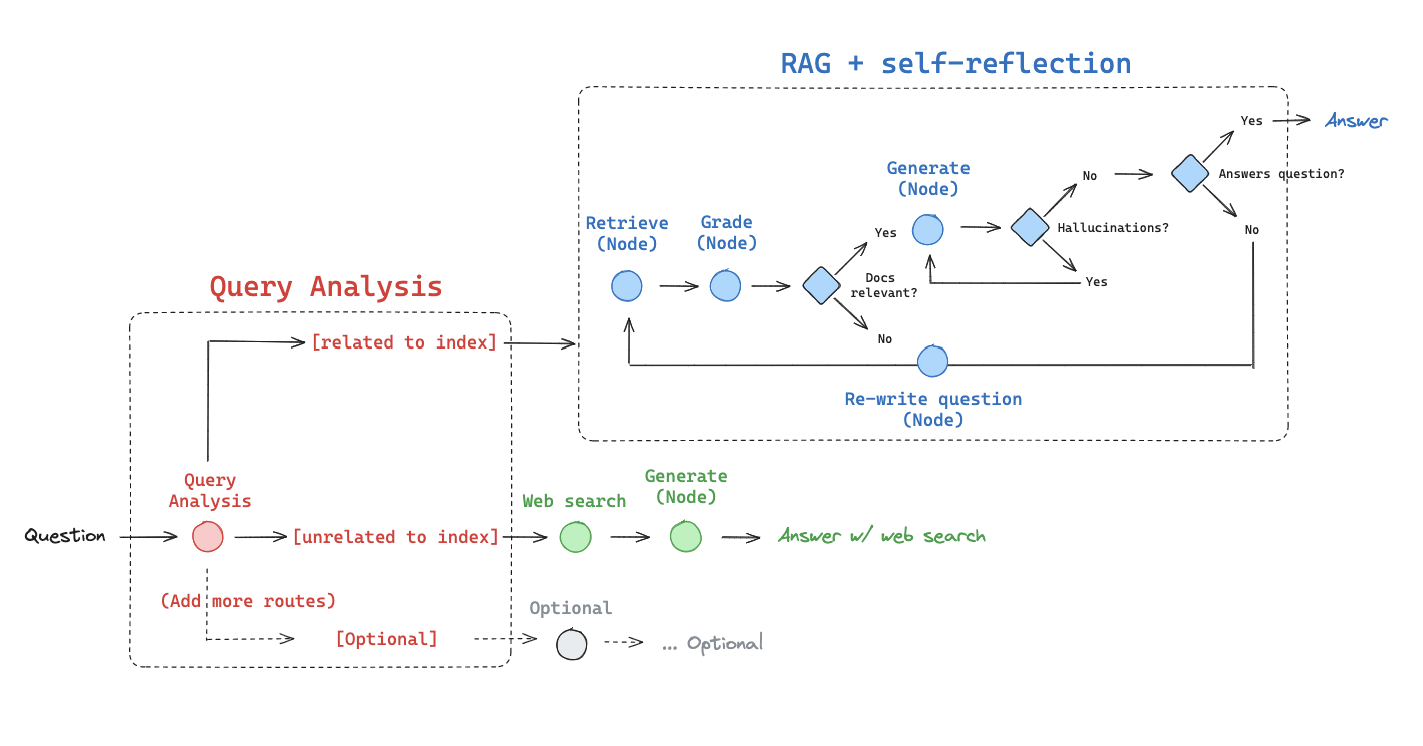
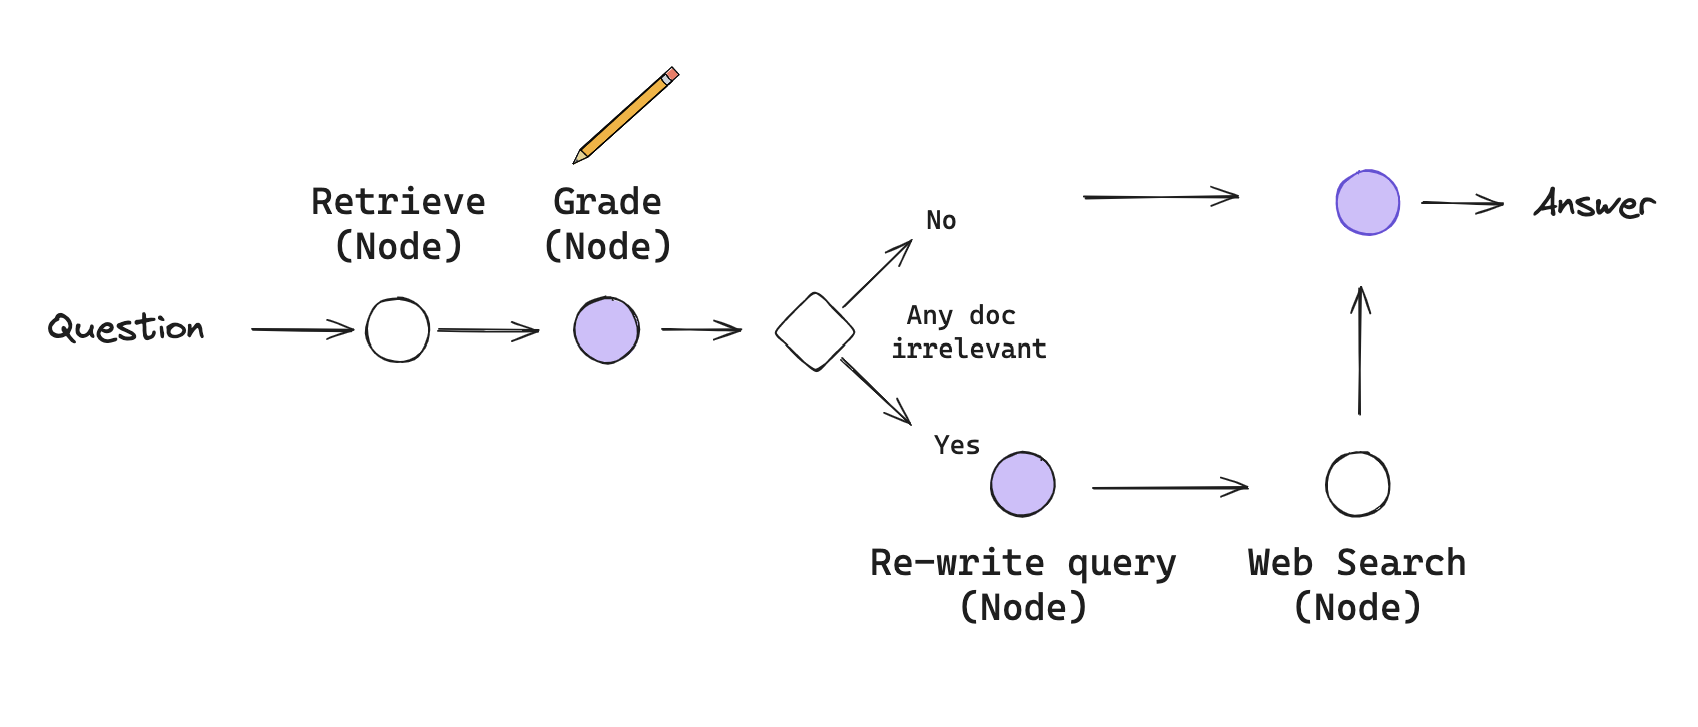

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]="ARAG"

### Corpus

Three Lilian Weng articles (agents / prompt engineering / adversarial attacks).
This corpus scope is ALSO what makes the router work - it routes *against these topics*.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document
import trafilatura

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]


documents = []
for url in urls:
    downloaded = trafilatura.fetch_url(url)
    # Extracts main text and converts to markdown while stripping site chrome
    clean_text = trafilatura.extract(
        downloaded, 
        output_format="markdown", 
        include_links=False
    )
    if clean_text:
        documents.append(Document(page_content=clean_text, metadata={"source": url}))

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(documents)

# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    persist_directory=os.path.join(os.getcwd(), "chroma.db"),
    embedding=OllamaEmbeddings(model='nomic-embed-text'),
)
retriever = vectorstore.as_retriever()

### Grader 1 - Question Router

4th reuse of `with_structured_output`. Routes to `vectorstore` (topics in our corpus)
or `web_search` (everything else). `temperature=0.1` - decisions should be stable.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
from typing import Literal


class Routequery(BaseModel):
    """Route a user query to the most relevant datasource"""

    datasource: Literal["vectorstore", "web_search"] = Field(
            description="Given a user question choose to route it to web search or a vectorstore.",
        )

llm = ChatOllama(model="gemma3:4b", temperature=0.1)
structured_llm = llm.with_structured_output(Routequery)

system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web-search."""

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

question_router  = route_prompt | structured_llm

print(
    question_router.invoke(
        {"question": "Who will the Bears draft first in the NFL draft?"}
    )
)
print(question_router.invoke({"question": "What are the types of agent memory?"}))

### Grader 2 - Document Relevance (ISREL)

Binary yes/no per document. This is Self-RAG's ISREL check implemented as an external
prompted judge - cheap to build, works with any model, but consistency depends on the
model (small local models flip verdicts between runs).

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field


class GradeDocs(BaseModel):
    """Binary score for releveant documents"""

    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

llm = ChatOllama(model="gemma3:4b", temperature=0.1)
structured_llm = llm.with_structured_output(GradeDocs)

system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm

question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

### Generator

Standard LCEL chain. Note the prompt's escape hatch: "respond 'I can't find...'
in the context" - honest failure beats confident hallucination downstream of graders.

In [ ]:
from langchain_classic import hub
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
# Role
You are an AI assistant focused on Question-Answering (QA) tasks within a Retrieval-Augmented Generation (RAG) system.
Your primary goal is to provide precise answers based on the given context or chat history.

# Instruction
Provide a concise, logical answer by organizing the selected content into coherent paragraphs with a natural flow. 
Avoid merely listing information. Include key numerical values, technical terms, jargon, and names. 
DO NOT use any outside knowledge or information that is not in the given material.

# Constraint
- Review the provided context thoroughly and extract key details related to the question.
- Craft a precise answer based on the relevant information.
- Keep the answer concise but logical/natural/in-depth.
- If the retrieved context does not contain relevant information or no context is available, respond with: 'I can't find the answer to that question in the context.'

**Source** (Optional)
- Cite the source of the information as a file name with a page number or URL, omitting the source if it cannot be identified.
- (list more if there are multiple sources)

# Question
<question>
{question}
</question>

# Context
<retrieved context>
{context}
</retrieved context>

# Answer
""" 
)

llm = ChatOllama(model="gemma3:4b")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = prompt | llm | StrOutputParser()

generation = rag_chain.invoke({"context": docs, "question": question})
generation

### Grader 3 - Hallucination Check (ISSUP)

"Is the generation grounded in the documents?" - Self-RAG's ISSUP check as a prompted
function. This is the stealable pattern mentioned in the Self-RAG discussion:
one extra call verifies grounding without any training.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field


class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

llm = ChatOllama(model="gemma3:4b", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

### Grader 4 - Answer Usefulness (ISUSE-adjacent)

Different failure mode than ISSUP: grounded but evasive (docs were right, answer dodges
the actual question). Both checks must pass for the answer to ship.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field

class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


llm = ChatOllama(model="gemma3:4b", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

### Corrective action - Query Rewriter

Query translation again (HyDE-era technique), now serving a new boss: when grading fails,
rewrite and retry instead of answering badly.

In [ ]:
llm = ChatOllama(model="gemma3:4b", temperature=0.1)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning. Respond only with the question"""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

### Fallback source - Tavily web search

Wrapped as a `@tool` (returns dict with `results`). Design decision from earlier discussion:
this graph uses web search ONLY as fallback - direct-routed questions get web results alone,
never mixed with local docs.

In [ ]:
import os
from langchain_core.tools import tool
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

@tool
def internet_search(
    query: str,
    max_results: int = 3,
) -> dict:
    """Search the internet for relevant sources."""
    return tavily_client.search(
        query,
        max_results=max_results,
    )

### Graph State - the contract

- Every key ANY node writes or reads MUST be declared here (LangGraph drops undeclared keys)
- Every node must assume it can be entered with only partial state -> use `.get()`
- `retries` exists purely as a loop breaker - control data lives in state too

In [ ]:
from typing import List, TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    retries: int
    documents: List[str]

### Nodes return STATE UPDATES, not answers

Each function gets the current state dict and returns only the keys it changes;
LangGraph merges them. All coordination happens through this shared dict - no function calls
between nodes.

In [ ]:
from langchain_core.documents import Document

def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [ ]:
def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

In [ ]:
def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    # Only fall back when NOTHING survived - a few good docs are enough to answer
    web_search = "Yes" if not filtered_docs else "No"
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


In [ ]:
def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    retries = state.get("retries", 0) + 1
    return {"documents": documents, "question": better_question, "retries": retries}

In [ ]:
def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    # Direct-routed questions have no documents yet - guard with .get()
    documents = state.get("documents", [])

    # Web search
    docs = internet_search.invoke({"query": question})
    results = docs.get("results", [])

    web_results_text = "\n".join([d["content"] for d in results if d.get("content")])
    web_result_doc = Document(page_content=web_results_text)
    documents.append(web_result_doc)

    return {"documents": documents, "question": question}

# web_search({"documents": documents, "question": question})

### Edge functions return ROUTE NAMES

`route_question` / `decide_to_generate` / `grade_generation_v_documents_and_question` are
not nodes - they are edge functions wired via `add_conditional_edges`. Their return string
must match a key in the mapping. Pure functions of state.

In [ ]:
def route_question(state):
    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE QUESTION---")
    question = state["question"]
    source = question_router.invoke({"question": question})
    if source.datasource == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"

In [ ]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    documents = state.get("documents", [])
    retries = state.get("retries", 0)

    if documents:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"
    elif retries < 2:
        # Nothing relevant yet - rewrite and try local retrieval again
        print("---DECISION: NOTHING RELEVANT, TRANSFORM QUERY---")
        return "transform_query"
    else:
        # Retried enough - give up on the corpus, fall back to web search
        print("---DECISION: RETRY LIMIT HIT, FALL BACK TO WEB SEARCH---")
        return "web_search"

### The decision ladder that prevents infinite loops

`decide_to_generate`: docs exist -> GENERATE | retries < 2 -> TRANSFORM | else -> WEB SEARCH

Worst case path terminates: 2 rewrites, then web fallback. Bounded-retry-with-fallback is the
standard safety pattern for every self-corrective graph.

In [ ]:
def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        pprint("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

### The whole flow

```mermaid
flowchart TD
    S([START]) --> R{router}
    R -->|"web_search topic"| WS[web_search]
    R -->|in corpus| RET[retrieve]
    RET --> GD[grade_docs]
    GD -->|docs ok| GEN[generate]
    GD -->|"nothing relevant"| TQ[transform_query]
    TQ -->|"retries < 2"| RET
    TQ -->|"retry limit hit"| WS
    WS --> GEN
    GEN -->|not supported| GEN
    GEN -->|not useful| TQ
    GEN -->|useful| E([END])
```

Every arrow maps to one `add_edge` / `add_conditional_edges` call below.

In [ ]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("web_search", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query

# Build graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "web_search": "web_search",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "retrieve")
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

# Compile
app = workflow.compile()

Watch the trace: first question exits via the short web branch; second exercises
retrieve -> grade. Compare which graders fired in each path (LangSmith has full traces).

In [ ]:
from pprint import pprint

# Run
inputs = {
    "question": "What player at the Bears expected to draft first in the 2024 NFL draft?"
}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

In [ ]:
inputs = {"question": "What are the types of agent memory?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])